# Practical 03 — Linear Regression and Residual Error

## 1. Aim & Objectives

**Aim:** To implement Simple Linear Regression using Scikit-Learn and compute the residual error.

**Objectives:**
1. Fit a straight line `charges = m * age + c` on the medical insurance dataset.
2. Evaluate the model using MSE, RMSE and the R² score on unseen test data.
3. Plot the fitted regression line and the residual (error) plot.

## 2. Complete Python Code


Shape of dataset : (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Slope (m)     : 240.597
Intercept (c) : 3876.929

MSE  : 135983957.48
RMSE : 11661.22
R2   : 0.1241


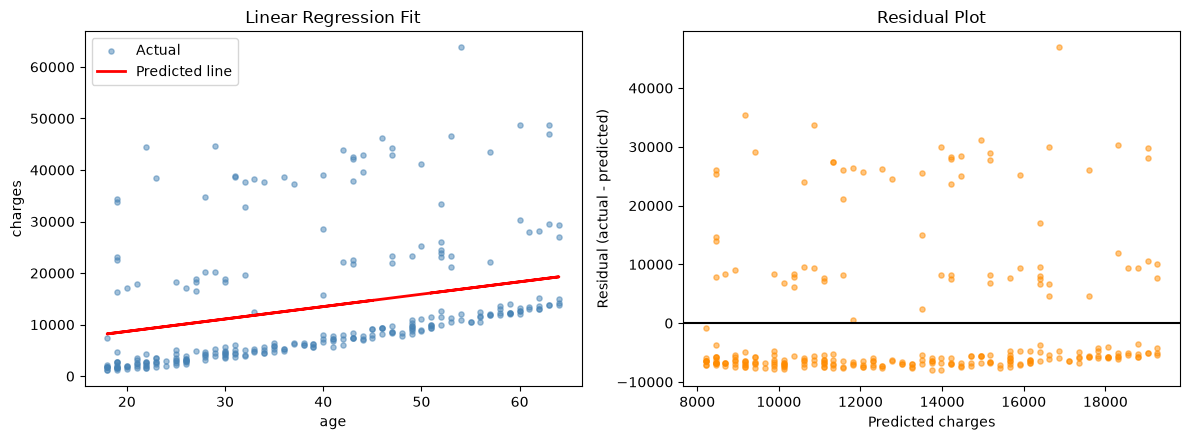

In [1]:
# Practical 03 - Linear Regression and Residual Error
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
CSV = "data/medical_insurance.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/03_Linear_Regression/data/medical_insurance.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print(df.head())

# Step 2: Choose input (X) and output (y)
X = df[["age"]]          # input must be 2-D
y = df["charges"]        # value we want to predict

# Step 3: Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nSlope (m)     :", round(model.coef_[0], 3))
print("Intercept (c) :", round(model.intercept_, 3))

# Step 5: Predict and measure the error
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print("\nMSE  :", round(mse, 2))
print("RMSE :", round(np.sqrt(mse), 2))
print("R2   :", round(r2_score(y_test, y_pred), 4))

# Step 6: Plot the regression line and the residuals
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].scatter(X_test, y_test, s=14, alpha=0.5, color="steelblue", label="Actual")
ax[0].plot(X_test, y_pred, color="red", linewidth=2, label="Predicted line")
ax[0].set_title("Linear Regression Fit")
ax[0].set_xlabel("age")
ax[0].set_ylabel("charges")
ax[0].legend()

ax[1].scatter(y_pred, residuals, s=14, alpha=0.5, color="darkorange")
ax[1].axhline(0, color="black", linewidth=1.5)
ax[1].set_title("Residual Plot")
ax[1].set_xlabel("Predicted charges")
ax[1].set_ylabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.linear_model import LinearRegression` — brings in the ready-made straight-line model.
- `from sklearn.metrics import mean_squared_error, r2_score` — functions that measure how wrong the model is.
- `from sklearn.model_selection import train_test_split` — splits the data into a training part and a testing part.
- `df = pd.read_csv(path)` — loads the insurance dataset (age, sex, bmi, children, smoker, region, charges).
- `X = df[["age"]]` — the input feature. Double brackets keep it as a table (2-D), which Scikit-Learn requires.
- `y = df["charges"]` — the value the model has to predict (single column, 1-D).
- `train_test_split(X, y, test_size=0.2, random_state=42)` — keeps 80% of rows for training and 20% for testing. `random_state=42` makes the split the same every time we run it.
- `model = LinearRegression()` — creates an empty model.
- `model.fit(X_train, y_train)` — learns the best slope and intercept from the training rows only.
- `model.coef_[0]` — the learned slope `m`, i.e. how much `charges` rises when `age` increases by 1 year.
- `model.intercept_` — the learned constant `c`, the value of the line at age = 0.
- `model.predict(X_test)` — uses the line to predict charges for the unseen test rows.
- `residuals = y_test - y_pred` — the error of every prediction (actual minus predicted).
- `mean_squared_error` — the average of the squared errors; `np.sqrt(mse)` converts it back to rupees/dollars as RMSE.
- `r2_score` — how much of the variation in `charges` the line explains; 1.0 is perfect, 0.0 is no better than the mean.
- `ax[0].scatter(...)` and `ax[0].plot(...)` — the real test points and the red fitted line drawn over them.
- `ax[1].scatter(y_pred, residuals)` with `axhline(0)` — the residual plot; the black line marks zero error.
- `plt.show()` — displays both graphs.


## 4. Output & Graph Interpretation

The fitted red line rises with age, which confirms a positive relationship — older customers are charged more on average.

The residual plot shows points spread far above the zero line in bands, so age alone cannot explain the full cost; the low R² tells us other features such as `smoker` are needed for a good model.
